In [1]:
!python --version

Python 3.9.7


**Working with Fonts and styles**

In [2]:
import openpyxl

In [3]:
work_book = openpyxl.load_workbook('student_data.xlsx')

In [4]:
work_book.sheetnames

['Sheet']

In [5]:
sheet = work_book['Sheet']

In [6]:
sheet['A1'].value

'Name'

In [7]:
## Lets go ahead and import a bunch of functionality from styles namespace of the openpyxl library.

In [8]:
from openpyxl.styles import Font, Color, Alignment, Border, Side, colors

In [9]:
## Lets start out by instantiating a font

bold_font = Font(bold=True)

big_red_text = Font(color=colors.BLUE, size=20)

center_aligned_text = Alignment(horizontal="center")

double_border_side = Side(border_style="double")## This is used to set the line boundaries between different cells.



In [10]:
square_border = Border(top=double_border_side,       ## double_border_side was instantiated above.
                       right=double_border_side,
                       bottom=double_border_side,
                       left=double_border_side)

In [11]:
## Lets apply it now

sheet["B2"].font = bold_font
sheet["B3"].font = big_red_text
sheet["C4"].alignment = center_aligned_text
sheet["C5"].border = square_border

In [12]:
work_book.save('student_data.xlsx')

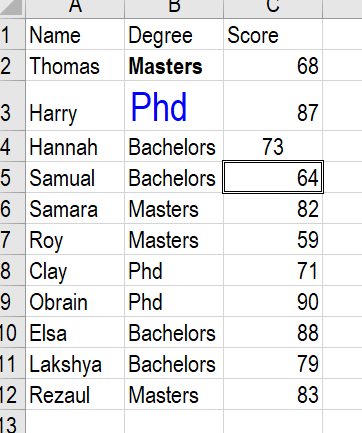

In [13]:
## Lets applying sty;ing for the same cell.

sheet["B7"].alignment = center_aligned_text
sheet["B7"].font = big_red_text
sheet["B7"].border = square_border

work_book.save('student_data.xlsx')

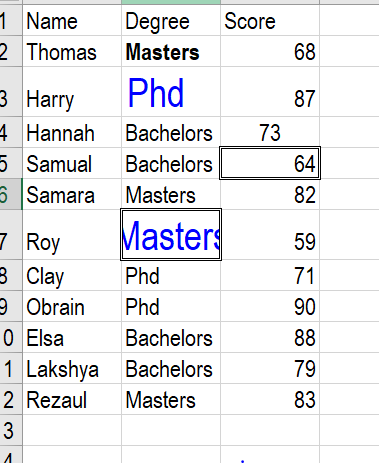

**Working with Borders and Colors**

In [14]:
##When we want to apply multiple styles to one or several cells, you can use a NamedStyle class instead, 
##which is like a style template that you can use over and over again.

##Lets start by importing the namedstyle module from the styles name space of openpyxl

In [15]:
from openpyxl.styles import NamedStyle

In [16]:
##Let's create a style template for the header row

custom_style = NamedStyle(name="header")

custom_style.font = Font(bold=True)

custom_style.border = Border(bottom=Side(border_style="thin")) ## This border is only one sided with the border style equal to thin

custom_style.alignment = Alignment(horizontal="center", vertical="center")

In [17]:
## Now that we have this custome style object the beauty of it is that we can go ahead and apply this custom style 
## to any rows or cells that we wish to. Lets extract the header row from our sheet.

In [18]:
header_row = sheet[1] ## we index into the sheet using an integer. the return value here is a single row.and that row is at index one.
## this command is gonna give us an handle to the first row.

In [19]:
## Lets apply our custom style to every cell in the header row.

for cell in header_row:
    cell.style= custom_style

ValueError: Style header exists already

In [21]:
work_book.save('student_data.xlsx') ## Notice the header highlighted with bottom line and centered

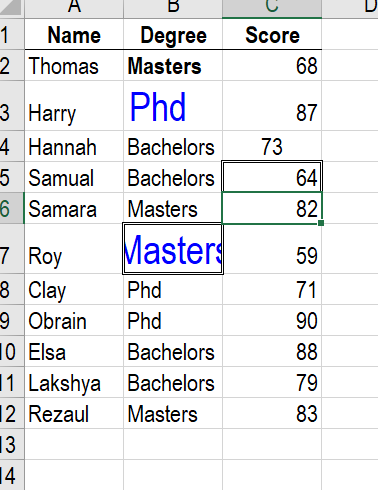

In [22]:
## Lets work with pattern fill

In [23]:
from openpyxl.styles.fills import PatternFill

In [24]:
one_more_style = NamedStyle(name="highlight")

In [25]:
## Lets set the fill property of this style to be the PatterFill

one_more_style.fill = PatternFill(fgColor=colors.Color('d7abcc'),  ## foreground color. its a hexcode
                                  patternType='lightHorizontal')

In [26]:
## Now we have the style objecy, lets apply it to all of the data in the spreadsheet

In [27]:
for cell in sheet['A']:  ## Indexing using the single column index A -> Col A
     cell.style = one_more_style ## These iterations will only be perfromed within the actual dimesnions of the spreadsheet,
                            ## i.e. where data is present

ValueError: Style highlight exists already

In [28]:
work_book.save('student_data.xlsx') ##even cell A13 has the style applied as we pressed the enter while entering the data.

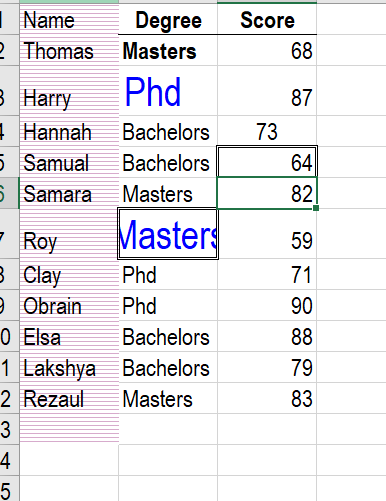

## Applying Number formats**


In [29]:
import openpyxl

In [34]:
work_book=openpyxl.load_workbook("100 Sales Records.xlsx")

In [36]:
work_book.active

<Worksheet "100 Sales Records">

In [37]:
work_book.sheetnames

['100 Sales Records']

In [38]:
sheet=work_book["100 Sales Records"]

In [39]:
sheet

<Worksheet "100 Sales Records">

In [41]:
sheet['a1'].value

'Region'

In [44]:
sheet.max_row

101

In [48]:
sheet.max_column

14

In [51]:
for row in sheet['l2':'n101']:
    for cell in row:
        print(cell.coordinate, cell.value)


L2 2533654
M2 1582243.5
N2 951410.5
L3 576782.8
M3 328376.44
N3 248406.36
L4 1158502.59
M4 933903.84
N4 224598.75
L5 75591.66
M5 56065.84
N5 19525.82
L6 3296425.02
M6 2657347.52
N6 639077.5
L7 759202.72
M7 474115.08
N7 285087.64
L8 2798046.49
M8 2104134.98
N8 693911.51
L9 1245112.92
M9 734896.26
N9 510216.66
L10 496101.1
M10 343986.9
N10 152114.2
L11 1356180.1
M11 772106.23
N11 584073.87
L12 19103.44
M12 11275.32
N12 7828.12
L13 455479.04
M13 149381.12
N13 306097.92
L14 902980.64
M14 296145.92
N14 606834.72
L15 5997054.98
M15 4509793.96
N15 1487261.02
L16 400558.73
M16 277739.67
N16 122819.06
L17 182825.44
M17 59960.32
N17 122865.12
L18 3039414.4
M18 1830670.16
N18 1208744.24
L19 257653.5
M19 172619.7
N19 85033.8
L20 2559474.1
M20 1924728.2
N20 634745.9
L21 2492526.12
M21 2154588.52
N21 337937.6
L22 1901836
M22 1187679
N22 714157
L23 324971.44
M23 202941.66
N23 122029.78
L24 339490.5
M24 216804
N24 122686.5
L25 20404.71
M25 15134.04
N25 5270.67
L26 414371.1
M26 287316.9
N26 127054.2
L2

In [52]:
for row in sheet['l2':'n101']:
    for cell in row:
        cell.number_format = '#,##0'


In [53]:
work_book.save('100 Sales Records.xlsx')

In [57]:
from openpyxl.styles import PatternFill, colors


In [58]:
from openpyxl.styles.differential import DifferentialStyle
from openpyxl.formatting.rule import Rule

In [107]:
yellow_background=PatternFill(bgColor=colors.BLUE)

In [100]:
diff_style = DifferentialStyle(fill=yellow_background)

In [101]:
rule = Rule(type="expression", dxf=diff_style)

In [102]:
rule.formula=['$N1<70000']

In [103]:
sheet.calculate_dimension()

'A1:N101'

In [104]:
sheet.conditional_formatting.add(sheet.calculate_dimension(),rule)

In [105]:
work_book.save('100 Sales Records.xlsx')

Objectives
use number formats to represent currencies and add comma separators
[Video description begins] Topic title: Applying Number Formats. The presenter is Vitthal Srinivasan. [Video description ends]

Let's keep going with this idea of manipulating cell formatting from openpyxl.

[Video description begins] He opens the sales_record file in the Microsoft Excel window and a message is displayed, which reads: Dataset source: http://eforexcel.com/wp/wp-content/uploads/2017/07/100-Sales-Records.zip. [Video description ends]

We'll now take this to a whole different level working with conditional formatting from Python. In this example, we will be making use of some simple dummy ecommerce data. This is taken from eforexcel.com. This is a handy resource which has got a bunch of useful links and other information for people interested in working with Excel. So we have ecommerce data here, representing sales in different regions, countries, with information about item type, sales channels, and so on.

We are going to make use of openpyxl in order to format this data and make it easier for us to interpret. To begin with, let's apply a simple bit of formatting. Let's add comma separators to the three columns over on the extreme right, total revenue, total cost, and total profit. Let's exit out of Excel and switch back over into Python. While exiting, let's not save any of the changes that we just made.

[Video description begins] He opens a file called "ConditionalFormatting" in the Jupyter Notebook. [Video description ends]

In Python, as always, we begin by importing openpyxl and then loading the workbook that we are interested in working with.

[Video description begins] He enters the following code: import openpyxl. He enters the following code, code starts: work_book = openpyxl.load_workbook("datasets/sales_record.xlsx"). Code ends. [Video description ends]

This is in the data sets folder, and it's called sales_record.xlsx. Once we have a handle to the workbook, the next item on the agenda is getting a handle to the active worksheet. We can do this using the active property on the work_book.

[Video description begins] He enters the following code: sheet = work_book.active. [Video description ends]

Let's store this reference in a variable called sheet and then use the max_row property of sheet in order to get a sense of how much data the sheet contains. max_row is 101 and max_column is 13.

[Video description begins] He enters the following code: sheet.max_row. He runs the code. The output reads: 101. [Video description ends]

Remember that columns in Excel are index starting from 1, so column A is equal to column 1.

[Video description begins] He enters the following code: sheet.max_column and executes it. The output reads: 13. [Video description ends]

13 tells us that we have the data up to column M. Let's now go ahead and apply the comma separators using a number format. This number format is something that we are going to apply to every cell in the range K2 through M101. The structure of this for loop ought to be quite familiar to us.

[Video description begins] He enters the following code, code starts: for row in sheet['K2:M101']: for cell in row: cell.number_format = ‘#,##0’. Code ends. [Video description ends]

Notice how we pass in the string K2:M101 as an index into the sheet object. We then iterate over all of the rows in this range, that's the outer for loop. There is also an inner for loop in which we iterate over each of the cells in each row. Finally, in the body of the inner for loop, we go ahead and apply the number format. The important bit to note about that number format is the comma.

This means that we want commas as thousand separators. In case you've not worked with number formats in Excel, you should know that the hash symbol is used to represent numbers which may or may not be present depending on the magnitude of the number. However, the 0 is used to represent numbers which we absolutely want Excel to display. That's all there is to it. Let's go ahead and save our workbook.

[Video description begins] He enters the following code, code starts: work_book.save("workbooks/sales_basic_conditional.xlsx"). Code ends. [Video description ends]

Switch back over to Microsoft Excel and re-open the spreadsheet.

[Video description begins] He switches to the sales_basic_conditional file in the Microsoft Excel window. [Video description ends]

And now when we resize columns K, L, and M, we find that these columns do indeed possess comma separators for all of their values. That was a good start, let's keep building on that. Let's exit out of Excel, go back to Python and now apply some pretty heavy duty conditional formatting. This requires a lot of import statements.

[Video description begins] He enters the following code, code starts: from openpyxl.styles import PatternFill, colors from openpyxl.styles.differential import DifferentialStyle from openpyxl.formatting.rule import Rule. Code ends. [Video description ends]

I'll pause for a moment. Take in how we import PatternFill, colors which is an enumeration, differential style, and then also the Rule module. The first operation we're going to try and accomplish is we're going to highlight all rows where the total profit is greater than a certain threshold in a bright yellow color. To do this, let's start out by creating a PatternFill object.

[Video description begins] He enters the following code, code starts: yellow_background = PatternFill(bgColor = colors.YELLOW). Code ends. [Video description ends]

We store this in a variable called yellow_background. Notice how we've got to specify the background color. That's the argument bgColor, and we set this to be equal to colors.YELLOW. Creating the PatternFill object was the first step, let's now go ahead and pass that yellow_background into a differential style object. 

[Video description begins] He enters the following code, code starts: diff_style = differentialStyle(fill = yellow_background). Code ends. [Video description ends]

This has the one input argument which we need to specify, which is the fill, and we set its value to be equal to that yellow_background. So we created a PatternFill object, we pass that into a differential style object. Let's now take this one step further and create a rule. That rule in turn will need to take in a type.

[Video description begins] He enters the following code, code starts: rule = Rule(type="expression", dxf = diff_style). Code ends. [Video description ends]

This is of type expression. And the differential style which has got to be applied to all data rows which satisfy the expression. We'll see in a moment how there are other rules which do not require us to specify an expression. But for now, let's keep going. We've yet to tell this rule what formula we would like it to evaluate. So let's go ahead and do that.

[Video description begins] He enters the following code: rule.formula = ["$M1<70000"]. [Video description ends]

And this here is really interesting. We are setting the formula property of our rule to be a list. Within that list, we could potentially have multiple expressions. We just choose to have one. That expression is expressed in the form of a simple predicate. That predicate compares the value of the cell M1 to an absolute value. Effectively, we are checking whether this particular row has total profit less than $70,000. But what's interesting is the use of the dollar sign in that cell formula.

Note how there is a $ before the M but there is no $ before the 1. This means that when this rule is applied to different data rows, Excel is going to have to be smart enough to figure out that M should remain unchanged. So the column reference to M is absolute, but the row reference is relative. So as the rule is applied to different rows, that 1 is going to be replaced by the corresponding row number. The next step is to find all of the data that we've got to apply this rule to. To do this, let's make use of the sheet's calculate_dimension method.

[Video description begins] He enters the following code: sheet.calculate_dimension(). [Video description ends]

This tells us the entire range within the sheet which contains data. And that here, is A1 through M101. So we can finally make the one call which ties all of this together.

[Video description begins] He runs the code. The output reads: 'A1:M101'. He enters the following code, code starts: sheet.conditional_formatting.add(sheet.calculate_dimension(), rule). Code ends. [Video description ends]

We are going to apply conditional_formatting. And that conditional_formatting is going to be applied to all of the cells containing data. That's why the first input argument is sheet.calculate_dimensions. And that conditional formatting is going to be in the form of a rule. That's the rule which we just created up above. Note how the conditional formatting property of a sheet can contain more than one such pair. So here, we've only applied the one conditional formatting expression, but there's nothing preventing us from invoking the same function yet again with a different rule and a different data range. This really was quite a complex bit of programming. Let's see if it's worked out. 

[Video description begins] He enters the following code, code starts: work_book.save("workbooks/sales_basic_conditional.xlsx"). Code ends. [Video description ends]

Let's save our workbook, and open it up once again in Microsoft Excel and check whether all of the rows which satisfy the rule are indeed highlighted in yellow. And the answer is yes. We can immediately see that all of the rows in our data where the value in column M, that is the total profit, is less than $70,000, all such rows are highlighted in bright yellow. We have successfully made use of some pretty complex conditional formatting from openpyxl.

## Applying Conditional Formatting - Skipped

## Advanced Cond Formatting

In [109]:
from openpyxl.formatting.rule import IconSetRule

In [110]:
work_book=openpyxl.load_workbook('zomato_reviews.xlsx')

In [111]:
sheet=work_book.active

In [112]:
icon_set_rule = IconSetRule(icon_style='4Arrows', type='num', values=[1,2,3,4])

In [113]:
sheet.max_row

9552

In [114]:
sheet.conditional_formatting.add('G2:G9552', icon_set_rule)

In [115]:
work_book.save('zomato_reviews.xlsx')

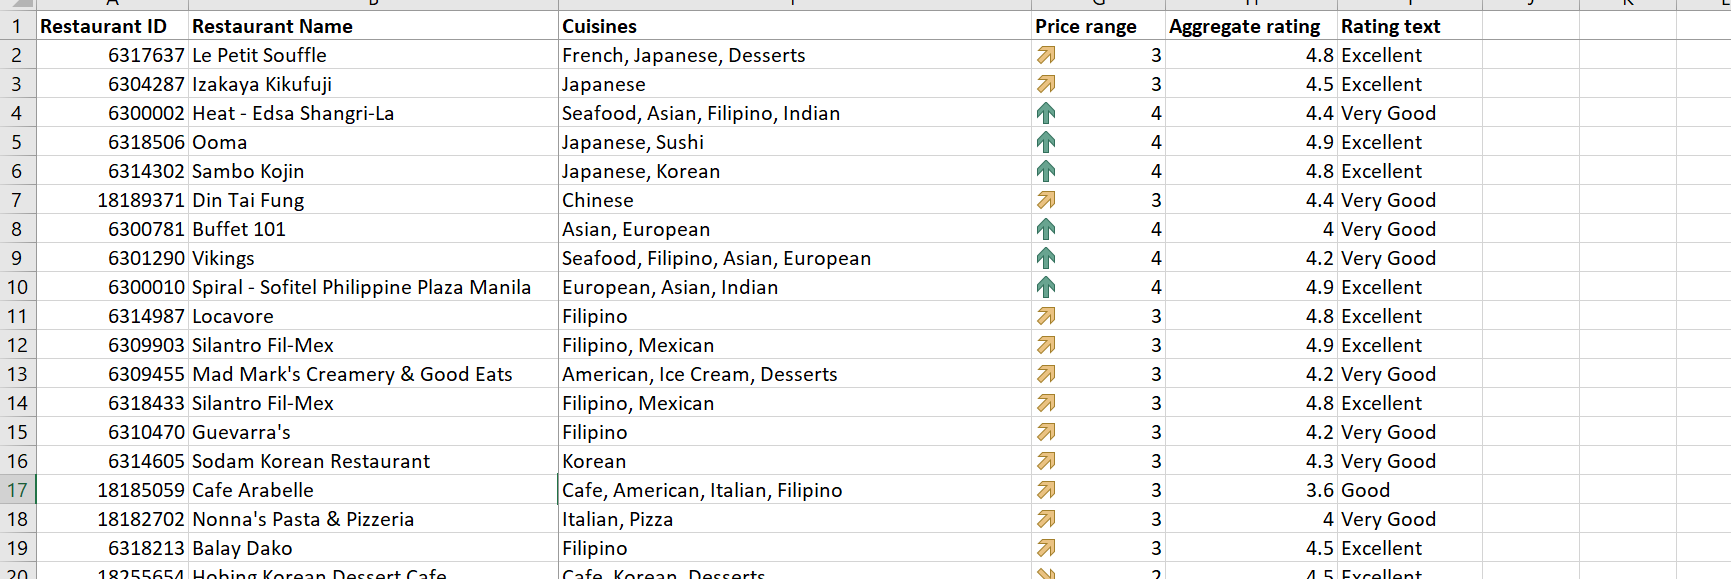

In [122]:
## Another type of formatting

from openpyxl.formatting.rule import DataBarRule

In [123]:
work_book=openpyxl.load_workbook('zomato_reviews.xlsx')

In [124]:
sheet=work_book.active

In [125]:
data_bar_rule=DataBarRule(start_type='num', start_value=1,end_type='num',end_value=4, color=colors.BLUE)

In [126]:
sheet.conditional_formatting.add('g2:g9552', data_bar_rule)

In [127]:
work_book.save('zomato_reviews.xlsx')

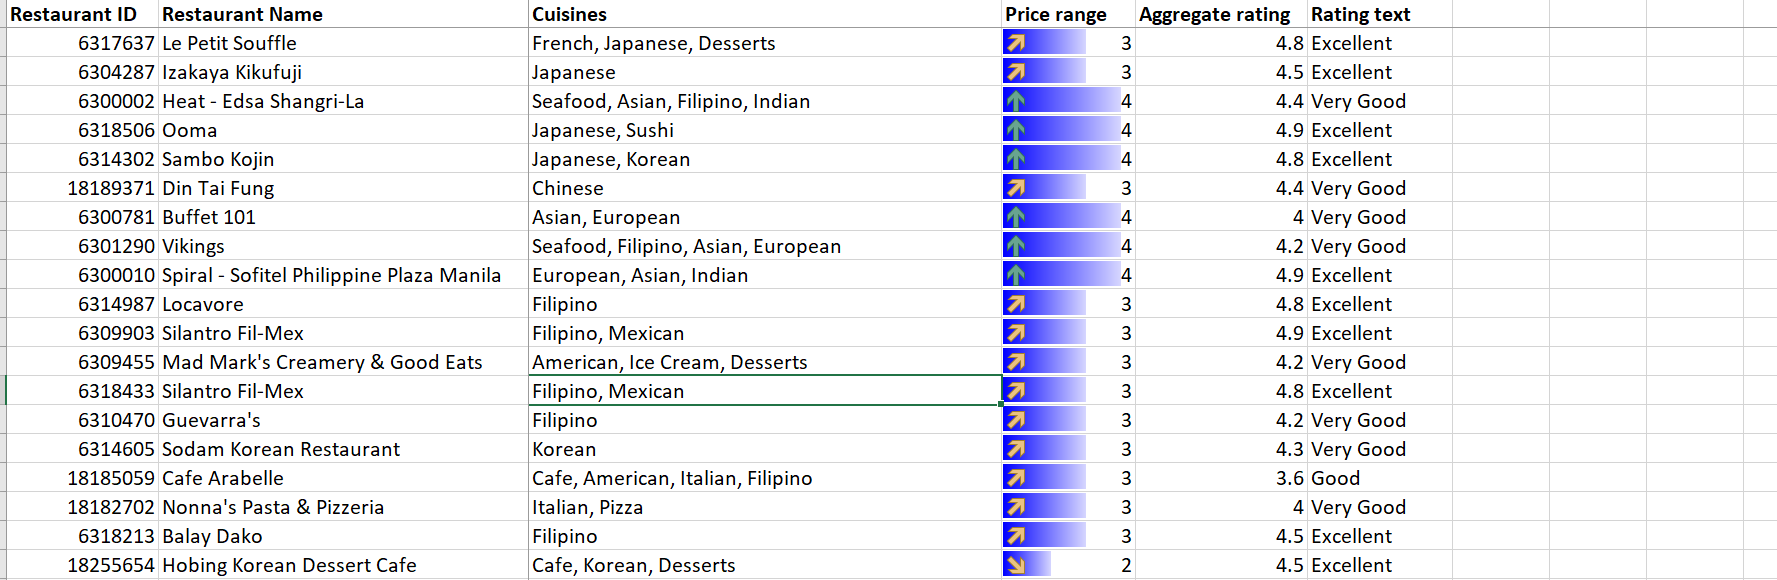

## Working with Images

In [140]:
from openpyxl import Workbook

In [141]:
from openpyxl.drawing.image import Image

In [142]:
work_book=openpyxl.Workbook()

In [144]:
work_book.sheetnames

['Sheet']

In [145]:
work_sheet=work_book.active

In [147]:
img=Image('IMG-7717.jpg')

In [148]:
work_sheet.add_image(img,'c11')

In [149]:
work_book.save('pythonimage.xlsx')

In [150]:
(img.width, img.height)

(750, 1624)

In [151]:
small_image = Image('IMG-7717.jpg')

In [152]:
small_image.width = 225
small_image.height = 225

In [162]:
work_sheet.add_image(small_image, 'L11')

In [164]:
work_book.save('pythonimage.xlsx')

## Working with Formulae

In [1]:
from openpyxl.utils import FORMULAE

In [2]:
FORMULAE

frozenset({'ABS',
           'ACCRINT',
           'ACCRINTM',
           'ACOS',
           'ACOSH',
           'AMORDEGRC',
           'AMORLINC',
           'AND',
           'AREAS',
           'ASC',
           'ASIN',
           'ASINH',
           'ATAN',
           'ATAN2',
           'ATANH',
           'AVEDEV',
           'AVERAGE',
           'AVERAGEA',
           'AVERAGEIF',
           'AVERAGEIFS',
           'BAHTTEXT',
           'BESSELI',
           'BESSELJ',
           'BESSELK',
           'BESSELY',
           'BETADIST',
           'BETAINV',
           'BIN2DEC',
           'BIN2HEX',
           'BIN2OCT',
           'BINOMDIST',
           'CEILING',
           'CELL',
           'CHAR',
           'CHIDIST',
           'CHIINV',
           'CHITEST',
           'CHOOSE',
           'CLEAN',
           'CODE',
           'COLUMN',
           'COLUMNS',
           'COMBIN',
           'COMPLEX',
           'CONCATENATE',
           'CONFIDENCE',
           'CO

In [3]:
import openpyxl

In [12]:
work_book=openpyxl.Workbook()

In [13]:
sheet=work_book.active

In [14]:
sheet['a1']=21
sheet['a2']=11
sheet['a3']=7
sheet['a4']=9
sheet['a5']=6

In [17]:
sheet['c2']= "SUM:"
sheet['d2']= "=SUM(a1:a5)"

In [18]:
work_book.save('formulae.xlsx')

In [23]:
sheet['c3']= "PRODUCT:"
sheet['d3']= "=PRODUCT(a1:a5)"

In [24]:
sheet['c4']= "COUNT:"
sheet['d4']= "=COUNT(a1:a10)"

In [25]:
sheet['c5']= "AVERAGE:"
sheet['d5']= "=AVERAGE(a1:a5)"

In [27]:
work_book.save('formulae.xlsx')

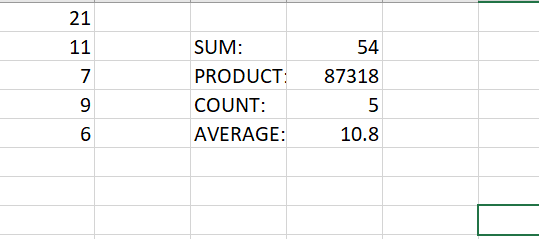

## More Operations using Formulae

In [28]:
header =['Cake', 'Quantity', 'Price', 'Revenue']

In [29]:
data = [['Chocolate',18,5],['Cheesecake', 13, 4.5],['Tres Lenches', 16,5.5],['Carrot', 8, 4], ['Red Velvet',9,4.5]]

In [30]:
work_book.sheetnames

['Sheet']

In [31]:
work_book.create_sheet('Cake Sales')

<Worksheet "Cake Sales">

In [32]:
sheet=work_book['Cake Sales']
sheet

<Worksheet "Cake Sales">

In [33]:
sheet.append(header)

In [34]:
for row in data:
    sheet.append(row)

In [35]:
work_book.save('formulae.xlsx')

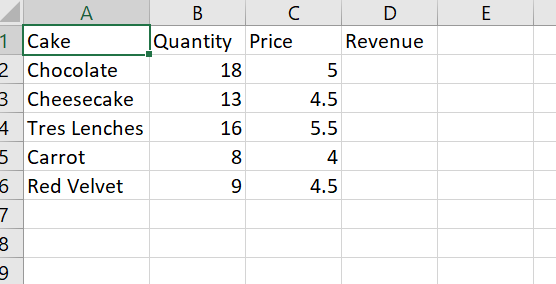

In [36]:
sheet['d2:d6']

((<Cell 'Cake Sales'.D2>,),
 (<Cell 'Cake Sales'.D3>,),
 (<Cell 'Cake Sales'.D4>,),
 (<Cell 'Cake Sales'.D5>,),
 (<Cell 'Cake Sales'.D6>,))

In [37]:
for row in sheet['c2:c6']:
    for cell in row:
        

5
4.5
5.5
4
4.5


In [38]:
work_book.create_sheet('test', index=0)

<Worksheet "test">

In [41]:
work_book.save('formulae.xlsx')

## Using Absolute and Relative Cell References

In [42]:
## Constructing Absolute and Relative Cell Ref directly in EXCEL. USe $ symbol for absolute cell references

## Programmatically Constructing Absolute references

In [49]:
sheet

<Worksheet "Cake Sales">

In [50]:
max_row_str = str(sheet.max_row)
max_row_str

'6'

In [51]:
for row in sheet['D2:D'+max_row_str]:
    for cell in row:
        cell.value = '=$B${0} * $C${0}'.format(cell.row)

In [52]:
work_book.save('formulae.xlsx')

In [53]:
totals_row_str = str(sheet.max_row + 2)

In [54]:
sheet['C'+totals_row_str]='Total Sales:'

In [55]:
sheet['D' + totals_row_str]='=sum(d2:d' + max_row_str + ')'

In [59]:
work_book.save('formulae.xlsx')

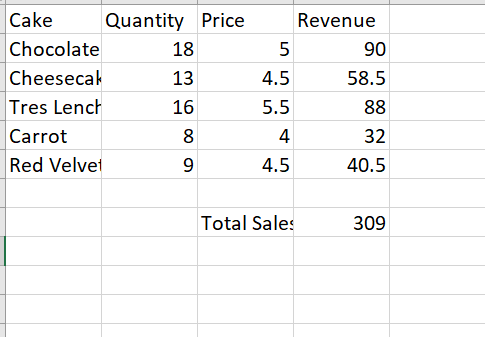

In [61]:
for row in sheet['c2:d'+ max_row_str]:
    for cell in row:
        cell.number_format = '$#,##0.00'

In [62]:
sheet['d8'].number_format = '$#,##0.00'

In [63]:
work_book.save('formulae.xlsx')

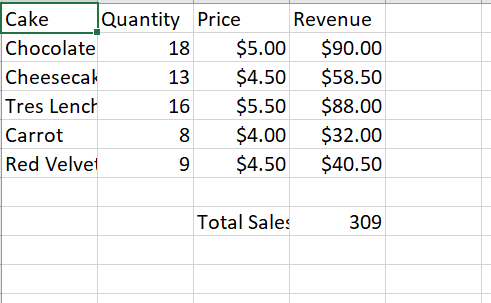

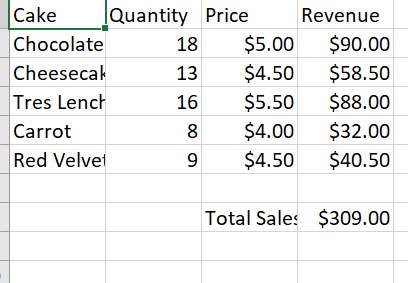


## Using Vlookup

In [5]:
## Created a new xls Products

import openpyxl

In [6]:
work_book = openpyxl.load_workbook('Products.xlsx')

In [7]:
work_book.sheetnames

['Products', 'Data']

In [8]:
sheet=work_book['Products']



In [9]:
sheet=work_book.active

In [10]:
sheet

<Worksheet "Products">

In [11]:
fx_range = work_book.defined_names['fx_rates']

In [12]:
fx_range

<openpyxl.workbook.defined_name.DefinedName object>
Parameters:
name='fx_rates', comment=None, customMenu=None, description=None, help=None, statusBar=None, localSheetId=None, hidden=None, function=None, vbProcedure=None, xlm=None, functionGroupId=None, shortcutKey=None, publishToServer=None, workbookParameter=None, attr_text='Data!$N$3:$O$11'

In [13]:
fx_range.destinations

<generator object DefinedName.destinations at 0x000001717057ADD0>

In [14]:
cells =[]

for title, coord in fx_range.destinations:
    ws =work_book[title]
    print(ws)
    cells.append(ws[coord])
    
cells

<Worksheet "Data">


[((<Cell 'Data'.N3>, <Cell 'Data'.O3>),
  (<Cell 'Data'.N4>, <Cell 'Data'.O4>),
  (<Cell 'Data'.N5>, <Cell 'Data'.O5>),
  (<Cell 'Data'.N6>, <Cell 'Data'.O6>),
  (<Cell 'Data'.N7>, <Cell 'Data'.O7>),
  (<Cell 'Data'.N8>, <Cell 'Data'.O8>),
  (<Cell 'Data'.N9>, <Cell 'Data'.O9>),
  (<Cell 'Data'.N10>, <Cell 'Data'.O10>),
  (<Cell 'Data'.N11>, <Cell 'Data'.O11>))]

In [15]:
max_row_str = str(sheet.max_row)

max_row_str

'8'

In [16]:
sheet['c2'].value

'=$B$2*VLOOKUP($c$2,fx_rates, 2, false)'

In [17]:
for row in sheet['c3:c' + max_row_str]:
    for cell in row:
        cell.value = '=$B${0}*VLOOKUP($c$2,fx_rates, 2, FALSE)'.format(cell.row)
        cell.number_format = '#,##0.00'
    

In [18]:
for row in sheet['d3:d' + max_row_str]:
    for cell in row:
        cell.value = '=$B${0}*VLOOKUP($d$2,fx_rates, 2, FALSE)'.format(cell.row)
        cell.number_format = '#,##0.00'
    

In [19]:
for row in sheet['e3:e' + max_row_str]:
    for cell in row:
        cell.value = '=$B${0}*VLOOKUP($e$2,fx_rates, 2, FALSE)'.format(cell.row)
        cell.number_format = '#,##0.00'
    

In [95]:
work_book.save('Products.xlsx')

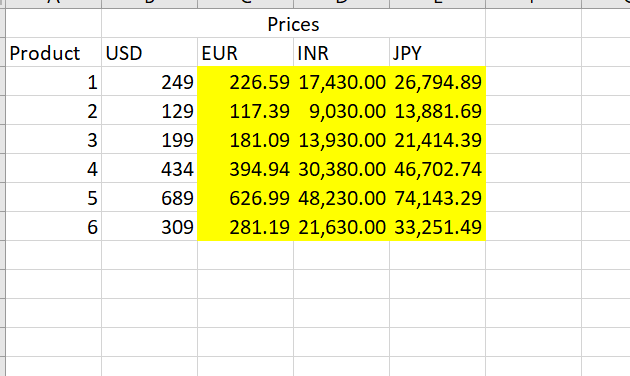

In [103]:
work_book.create_named_range('Products2', sheet, '$A$3:$C' + max_row_str)

In [21]:
work_book.save('Products.xlsx')

In [20]:
for row in sheet['f3:f' + max_row_str]:
    for cell in row:
        cell.value = '=$B${0}*VLOOKUP($f$2,fx_rates, 2, FALSE)'.format(cell.row)
        cell.number_format = '#,##0.00'

## Working with Pivot tables

In [22]:
## Just an excel example of Pivot table using the 100 Sales Records xlsx.

## Using Pandas for Pivoting

In [23]:
import pandas as pd

In [24]:
sales_df = pd.read_excel('100 Sales Records.xlsx')

In [27]:
sales_df.head()

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
0,Australia and Oceania,Tuvalu,Baby Food,Offline,H,2010-05-28,669165933,2010-06-27,9925,255.28,159.42,2533654.00,1582243.50,951410.50
1,Central America and the Caribbean,Grenada,Cereal,Online,C,2012-08-22,963881480,2012-09-15,2804,205.70,117.11,576782.80,328376.44,248406.36
2,Europe,Russia,Office Supplies,Offline,L,2014-05-02,341417157,2014-05-08,1779,651.21,524.96,1158502.59,933903.84,224598.75
3,Sub-Saharan Africa,Sao Tome and Principe,Fruits,Online,C,2014-06-20,514321792,2014-07-05,8102,9.33,6.92,75591.66,56065.84,19525.82
4,Sub-Saharan Africa,Rwanda,Office Supplies,Offline,L,2013-02-01,115456712,2013-02-06,5062,651.21,524.96,3296425.02,2657347.52,639077.50


In [29]:
sales_df.sort_values(by=['Region','Country','Item Type']).head(10)

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
12,Asia,Bangladesh,Clothes,Online,L,2017-01-13,187310731,2017-03-01,8263,109.28,35.84,902980.64,296145.92,606834.72
38,Asia,Brunei,Office Supplies,Online,L,2012-04-01,320009267,2012-05-08,6708,651.21,524.96,4368316.68,3521431.68,846885.00
10,Asia,Kyrgyzstan,Vegetables,Online,H,2011-06-24,814711606,2011-07-12,124,154.06,90.93,19103.44,11275.32,7828.12
77,Asia,Laos,Vegetables,Offline,C,2011-09-15,789176547,2011-10-23,3732,154.06,90.93,574951.92,339350.76,235601.16
96,Asia,Malaysia,Fruits,Offline,L,2011-11-11,810711038,2011-12-28,6267,9.33,6.92,58471.11,43367.64,15103.47
14,Asia,Mongolia,Personal Care,Offline,C,2014-02-19,832401311,2014-02-23,4901,81.73,56.67,400558.73,277739.67,122819.06
44,Asia,Myanmar,Clothes,Online,H,2015-11-14,223359620,2015-11-18,5930,109.28,35.84,648030.40,212531.20,435499.20
33,Asia,Myanmar,Household,Offline,H,2015-01-16,177713572,2015-03-01,8250,668.27,502.54,5513227.50,4145955.00,1367272.50
16,Asia,Sri Lanka,Cosmetics,Offline,M,2016-11-19,419123971,2016-12-18,6952,437.20,263.33,3039414.40,1830670.16,1208744.24
18,Asia,Turkmenistan,Household,Offline,L,2010-12-30,441619336,2011-01-20,3830,668.27,502.54,2559474.10,1924728.20,634745.90


In [30]:
sales_df.sort_values(by=['Region','Country','Item Type']).tail(10)

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
9,Sub-Saharan Africa,Senegal,Cereal,Online,H,2014-04-18,616607081,2014-05-30,6593,205.70,117.11,1356180.10,772106.23,584073.87
53,Sub-Saharan Africa,Sierra Leone,Office Supplies,Offline,M,2011-11-26,441888415,2012-01-07,3457,651.21,524.96,2251232.97,1814786.72,436446.25
90,Sub-Saharan Africa,Sierra Leone,Office Supplies,Offline,H,2016-12-06,621386563,2016-12-14,948,651.21,524.96,617347.08,497662.08,119685.00
97,Sub-Saharan Africa,Sierra Leone,Vegetables,Offline,C,2016-06-01,728815257,2016-06-29,1485,154.06,90.93,228779.10,135031.05,93748.05
31,Sub-Saharan Africa,South Sudan,Personal Care,Offline,C,2013-12-29,406502997,2014-01-28,2125,81.73,56.67,173676.25,120423.75,53252.50
87,Sub-Saharan Africa,The Gambia,Baby Food,Offline,M,2014-02-03,494747245,2014-03-20,5559,255.28,159.42,1419101.52,886215.78,532885.74
42,Sub-Saharan Africa,The Gambia,Cereal,Offline,H,2012-06-07,994022214,2012-06-08,2117,205.70,117.11,435466.90,247921.87,187545.03
29,Sub-Saharan Africa,The Gambia,Household,Offline,L,2012-05-26,886494815,2012-06-09,2370,668.27,502.54,1583799.90,1191019.80,392780.10
37,Sub-Saharan Africa,The Gambia,Meat,Online,M,2017-01-14,825304400,2017-01-23,4767,421.89,364.69,2011149.63,1738477.23,272672.40
83,Sub-Saharan Africa,Zambia,Snacks,Online,L,2011-01-04,122583663,2011-01-05,4085,152.58,97.44,623289.30,398042.40,225246.90


In [31]:
import numpy as np


In [33]:
table = pd.pivot_table(sales_df,
                      index = ['Region', 'Country'],
                      values =['Units Sold', 'Total Revenue', 'Total Profit'],
                      aggfunc=[np.sum])

table.head(10)

sum                         
                                   Total Profit Total Revenue Units Sold
Region                Country                                           
Asia                  Bangladesh      606834.72     902980.64       8263
                      Brunei          846885.00    4368316.68       6708
                      Kyrgyzstan        7828.12      19103.44        124
                      Laos            235601.16     574951.92       3732
                      Malaysia         15103.47      58471.11       6267
                      Mongolia        122819.06     400558.73       4901
                      Myanmar        1802771.70    6161257.90      14180
                      Sri Lanka      1208744.24    3039414.40       6952
                      Turkmenistan   1267258.40    5822036.20       8840
Australia and Oceania Australia       576605.12    2489933.49      12995

In [34]:
table.loc['Asia', :]

sum                         
             Total Profit Total Revenue Units Sold
Country                                           
Bangladesh      606834.72     902980.64       8263
Brunei          846885.00    4368316.68       6708
Kyrgyzstan        7828.12      19103.44        124
Laos            235601.16     574951.92       3732
Malaysia         15103.47      58471.11       6267
Mongolia        122819.06     400558.73       4901
Myanmar        1802771.70    6161257.90      14180
Sri Lanka      1208744.24    3039414.40       6952
Turkmenistan   1267258.40    5822036.20       8840

In [36]:
table.loc[('Asia','Myanmar'), :]

sum  Total Profit     1802771.7
     Total Revenue    6161257.9
     Units Sold         14180.0
Name: (Asia, Myanmar), dtype: float64

## Leveraging Multi level indexing in Pandas

In [38]:
table.index.get_level_values(0)

Index(['Asia', 'Asia', 'Asia', 'Asia', 'Asia', 'Asia', 'Asia', 'Asia', 'Asia',
       'Australia and Oceania', 'Australia and Oceania',
       'Australia and Oceania', 'Australia and Oceania',
       'Australia and Oceania', 'Australia and Oceania',
       'Australia and Oceania', 'Australia and Oceania',
       'Australia and Oceania', 'Central America and the Caribbean',
       'Central America and the Caribbean',
       'Central America and the Caribbean',
       'Central America and the Caribbean',
       'Central America and the Caribbean',
       'Central America and the Caribbean', 'Europe', 'Europe', 'Europe',
       'Europe', 'Europe', 'Europe', 'Europe', 'Europe', 'Europe', 'Europe',
       'Europe', 'Europe', 'Europe', 'Europe', 'Europe', 'Europe', 'Europe',
       'Europe', 'Europe', 'Middle East and North Africa',
       'Middle East and North Africa', 'Middle East and North Africa',
       'Middle East and North Africa', 'Middle East and North Africa',
       'Middle East

In [40]:
unique_regions = table.index.get_level_values(0).unique()


unique_regions

Index(['Asia', 'Australia and Oceania', 'Central America and the Caribbean',
       'Europe', 'Middle East and North Africa', 'North America',
       'Sub-Saharan Africa'],
      dtype='object', name='Region')

In [41]:
unique_countries = table.index.get_level_values(1).unique()

unique_countries


Index(['Bangladesh', 'Brunei', 'Kyrgyzstan', 'Laos', 'Malaysia', 'Mongolia',
       'Myanmar', 'Sri Lanka', 'Turkmenistan', 'Australia', 'East Timor',
       'Federated States of Micronesia', 'Fiji', 'Kiribati', 'New Zealand',
       'Samoa ', 'Solomon Islands', 'Tuvalu', 'Belize', 'Costa Rica',
       'Grenada', 'Haiti', 'Honduras', 'Nicaragua', 'Albania', 'Austria',
       'Bulgaria', 'France', 'Iceland', 'Lithuania', 'Macedonia', 'Moldova ',
       'Monaco', 'Norway', 'Portugal', 'Romania', 'Russia', 'San Marino',
       'Slovakia', 'Slovenia', 'Spain', 'Switzerland', 'United Kingdom',
       'Azerbaijan', 'Iran', 'Kuwait', 'Lebanon', 'Libya', 'Pakistan',
       'Saudi Arabia', 'Syria', 'Mexico', 'Angola', 'Burkina Faso', 'Cameroon',
       'Cape Verde', 'Comoros', 'Cote d'Ivoire',
       'Democratic Republic of the Congo', 'Djibouti', 'Gabon', 'Kenya',
       'Lesotho', 'Madagascar', 'Mali', 'Mauritania', 'Mozambique', 'Niger',
       'Republic of the Congo', 'Rwanda', 'Sao Tome an

In [42]:
for region in unique_regions:
    print(table.loc[(region),:])

                      sum                         
             Total Profit Total Revenue Units Sold
Country                                           
Bangladesh      606834.72     902980.64       8263
Brunei          846885.00    4368316.68       6708
Kyrgyzstan        7828.12      19103.44        124
Laos            235601.16     574951.92       3732
Malaysia         15103.47      58471.11       6267
Mongolia        122819.06     400558.73       4901
Myanmar        1802771.70    6161257.90      14180
Sri Lanka      1208744.24    3039414.40       6952
Turkmenistan   1267258.40    5822036.20       8840
                                        sum                         
                               Total Profit Total Revenue Units Sold
Country                                                             
Australia                         576605.12    2489933.49      12995
East Timor                        337937.60    2492526.12       5908
Federated States of Micronesia    146875.14

In [45]:
writer = pd.ExcelWriter('100 Sales Records.xlsx')

for region in unique_regions:
    temp_df = table.loc[(region), :]
    temp_df.to_excel(writer, region)
    
writer.save()

InvalidWorksheetName: Excel worksheet name 'Central America and the Caribbean' must be <= 31 chars.